# Autoencoder Experiments

We conduct 3 experiment in an attempt of improving the anomaly detection system built with the autoencoder framework. Experiments will be done on main model that was built and finetuned in `autoencoder.ipynb`

The experiments will be as follows:
- Anomaly score \
  We try to improve anomaly score by incorporating another metric: Structural Similarity Index Measure (SSIM).
- Training logic \
  We try to force model to learn normal digits representation by implementing self-supervised masking and denoising (inpainting)
- Inference logic \
  We try to improve inference by evaluating input transformation ensemble via multi-rotation variance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import copy
import os
from piq import ssim

from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

from common.plots import plot_anomaly_distribution, plot_fbeta_vs_threshold, plot_performance_curves, plot_reconstructions, plot_loss
from common.autoencoder.evaluation import score_images, get_reconstructions, print_metrics
from common.autoencoder.training import train_autoencoder
from common.autoencoder.autoencoder import Autoencoder
from common.io import load_and_split_mnist
from common.config import MNIST_RAW_PATH, FIGS_DIR, DATA_WEIGHTS_DIR
from common.utils import set_seed
from common.finetuning import optimize_via_zooming_grid, optimize_fbeta_threshold

from typing import Tuple, Dict, Any, Callable, Type
from torch.optim import Optimizer
from torch import Tensor

SAVE_DIR = FIGS_DIR / "ae_experiments"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
SEED = 42
rs = set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
train_normal, val_normal, val_anomaly, test_normal, test_anomaly = load_and_split_mnist(
    mnist_path=MNIST_RAW_PATH,
    val_anomaly_digit=8,
    test_anomaly_digit=4,
    random_seed=SEED
)

print("Train splits:")
print(f"train_normal: \tX={train_normal[0].shape}, y={train_normal[1].shape}")

print("\nValidation splits:")
print(f"val_normal:   \tX={val_normal[0].shape}, y={val_normal[1].shape}")
print(f"val_anomaly:  \tX={val_anomaly[0].shape}, y={val_anomaly[1].shape}")

print("\nTest splits:")
print(f"test_normal:  \tX={test_normal[0].shape}, y={test_normal[1].shape}")
print(f"test_anomaly: \tX={test_anomaly[0].shape}, y={test_anomaly[1].shape}")

Train splits:
train_normal: 	X=torch.Size([44304, 784]), y=torch.Size([44304, 10])

Validation splits:
val_normal:   	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
val_anomaly:  	X=torch.Size([974, 784]), y=torch.Size([974, 10])

Test splits:
test_normal:  	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
test_anomaly: 	X=torch.Size([982, 784]), y=torch.Size([982, 10])


In [4]:
train_images = train_normal[0].reshape(train_normal[0].shape[0], 1, 28, 28)

train_dataset = TensorDataset(train_images, train_normal[1])
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=2048,
    shuffle=True,
    generator=torch.Generator(device="cpu").manual_seed(SEED),
    num_workers=os.cpu_count(),
    pin_memory=True
)

## Model loading and evaluation

In [5]:
train = torch.load(DATA_WEIGHTS_DIR / "ae_base_train.pt", map_location=device, weights_only=False)
config = torch.load(DATA_WEIGHTS_DIR / "ae_base_config.pt", map_location=device, weights_only=False)

print(train.keys())
print(config.keys())

dict_keys(['weights', 'losses', 'best_threshold', 'beta', 'best_results'])
dict_keys(['autoencoder_kwargs', 'optimizer_kwargs', 'criterion_fn', 'corruption_fn'])


In [6]:
optimizer_cls = torch.optim.Adam

model = Autoencoder(**config["autoencoder_kwargs"]).to(device)
model.load_state_dict(train["weights"])
optimizer = optimizer_cls(model.parameters(), **config["optimizer_kwargs"])

In [7]:
beta = train["beta"]
best_threshold = train["best_threshold"]
best_results = train["best_results"]

print_metrics(
    y_true = best_results["y_true"],
    y_scores = best_results["y_scores"],
    threshold = best_threshold,
    beta = beta
)

--- Evaluation Metrics ---
Best threshold for F2.0-score: 0.022566
Accuracy:  0.9089
Precision: 0.6941
Recall:    0.9528
F2.0 score:  0.8867

Confusion matrix:
[[3613  409]
 [  46  928]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9874    0.8983    0.9408      4022
         1.0     0.6941    0.9528    0.8031       974

    accuracy                         0.9089      4996
   macro avg     0.8408    0.9255    0.8719      4996
weighted avg     0.9302    0.9089    0.9139      4996



## Exp.1 Anomaly Score Formulation

Currently, both models utilize Mean Squared Error (MSE) as the anomaly measure. This approach strictly accounts for per-pixel differences without considering more general structural differences of the images. We assume that incorporating the Structural Similarity Index Measure (SSIM) will improve robustness and peformance. We propose a hybrid anomaly score controlled by a tuning parameter $\alpha$.

$$ AS(\alpha) = \alpha MSE + (1 - \alpha)(1 - SSIM) $$

, where

$$ SSIM(x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)} $$


In [ ]:
from piq import ssim

class HybridLoss(nn.Module):
    def __init__(self, alpha = 0.5):
        super().__init__()
        self.alpha = alpha

    def forward(self, x_hat, x, reduction = "mean"):
        loss_mse = nn.functional.mse_loss(x_hat, x, reduction = reduction)
        if loss_mse.ndim > 1:
            loss_mse = torch.mean(loss_mse, dim=tuple([i for i in range(1, loss_mse.ndim)]))
        # SSIM is 1 for identical images, so we minimize (1 - (ssim + 1)/2) = (1 - ssim)/2
        loss_ssim = (1.0 - ssim(x_hat, x, data_range = 1.0, reduction = reduction)) / 2.0

        return (self.alpha * loss_mse) + ((1 - self.alpha) * loss_ssim)

criterion_cls = HybridLoss

In [9]:
autoencoder_kwargs = config["autoencoder_kwargs"]
optimizer_kwargs = config["optimizer_kwargs"]

optimizer_cls = torch.optim.Adam
optimizer_kwargs = {
    "lr": 5e-3
}

In [10]:
val_normal_X = val_normal[0].to(device)
val_anomaly_X = val_anomaly[0].to(device)

per_model_data = {
    "alpha": [],
    "losses": []
}

def ae_score_callback(alpha: float) -> Tuple[np.ndarray, np.ndarray]:
    set_seed(SEED)
    train_loader.generator.manual_seed(SEED)

    model = Autoencoder(**autoencoder_kwargs).to(device)
    optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)
    current_criterion = criterion_cls(alpha=alpha)

    losses = train_autoencoder(
        model = model,
        train_loader = train_loader,
        criterion_fn = current_criterion,
        optimizer = optimizer,
        device = device,
        loss_eps = 1e-3,
        patience = 5,
        max_epochs = 100,
        corruption_fn = None,
        verbose = True
    )

    per_model_data["alpha"].append(alpha)
    per_model_data["losses"].append(losses)

    val_normal_scores = score_images(model, val_normal_X, device, criterion_fn = current_criterion)
    val_anomaly_scores = score_images(model, val_anomaly_X, device, criterion_fn = current_criterion)

    return val_normal_scores, val_anomaly_scores

best_alpha, best_auc, history = optimize_via_zooming_grid(
    score_fn = ae_score_callback,
    param_min = 0.0,
    param_max = 1.0,
    size = 5,
    depth = 3,
    param_name = "alpha",
    is_integer = False,
    verbose = True
)

print(f"Best Alpha: {best_alpha:.5e} with PR AUC: {best_auc:.5e}")


Zoom Step 1/3 Interval: [0.0000, 1.0000]
alpha      | PR AUC    


[Early Stopped at Epoch 9]: : 9 epoch [00:09,  1.02s/ epoch, Loss=4.270e-01, Best=4.253e-01, Patience=5/5]


0.0000     | 0.1620    


[Early Stopped at Epoch 58]: : 58 epoch [00:56,  1.02 epoch/s, Loss=5.153e-02, Best=5.223e-02, Patience=5/5]


0.2000     | 0.7960    


...

0.8100     | 0.8377    


[Early Stopped at Epoch 34]: : 34 epoch [00:39,  1.15s/ epoch, Loss=2.215e-02, Best=2.306e-02, Patience=5/5]


0.8410     | 0.7944    


[Early Stopped at Epoch 32]: : 32 epoch [00:36,  1.15s/ epoch, Loss=2.162e-02, Best=2.233e-02, Patience=5/5]

0.8720     | 0.7617    
Best Alpha: 8.10000e-01 with PR AUC: 8.37737e-01


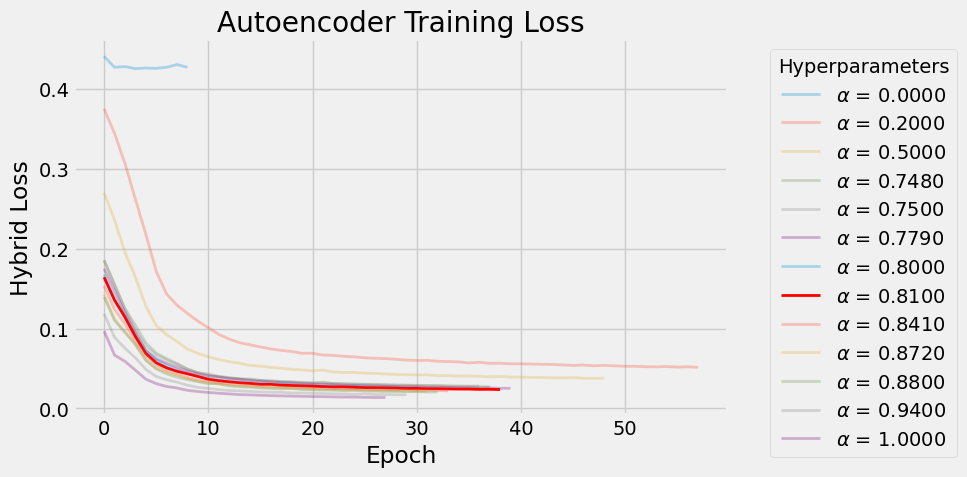

In [11]:
alpha_loss_dict = dict(zip(per_model_data["alpha"], per_model_data["losses"]))

plot_loss(
    losses=alpha_loss_dict,
    highlight_key=best_alpha,
    label_prefix=r"$\alpha$ = ",
    loss_prefix="Hybrid ",
    legend_title="Hyperparameters",
    save_path=SAVE_DIR / "exp1_all_alphas_epoch_loss.png"
)

In [59]:
set_seed(SEED)
train_loader.generator.manual_seed(SEED)

model = Autoencoder(**autoencoder_kwargs).to(device)
optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)
criterion_fn = criterion_cls(alpha=best_alpha)

losses = train_autoencoder(
    model = model,
    train_loader = train_loader,
    criterion_fn = criterion_fn,
    optimizer = optimizer,
    device = device,
    loss_eps = 1e-4,
    patience = 5,
    max_epochs = 100,
    corruption_fn = None,
    verbose = True
)

[Early Stopped at Epoch 78]: : 78 epoch [01:31,  1.17s/ epoch, Loss=2.068e-02, Best=2.074e-02, Patience=5/5]


--- Evaluation Metrics ---
Best threshold for F2.0-score: 0.041686
Accuracy:  0.9073
Precision: 0.6922
Recall:    0.9446
F2.0 score:  0.8804

Confusion matrix:
[[3613  409]
 [  54  920]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9853    0.8983    0.9398      4022
         1.0     0.6922    0.9446    0.7990       974

    accuracy                         0.9073      4996
   macro avg     0.8388    0.9214    0.8694      4996
weighted avg     0.9281    0.9073    0.9123      4996



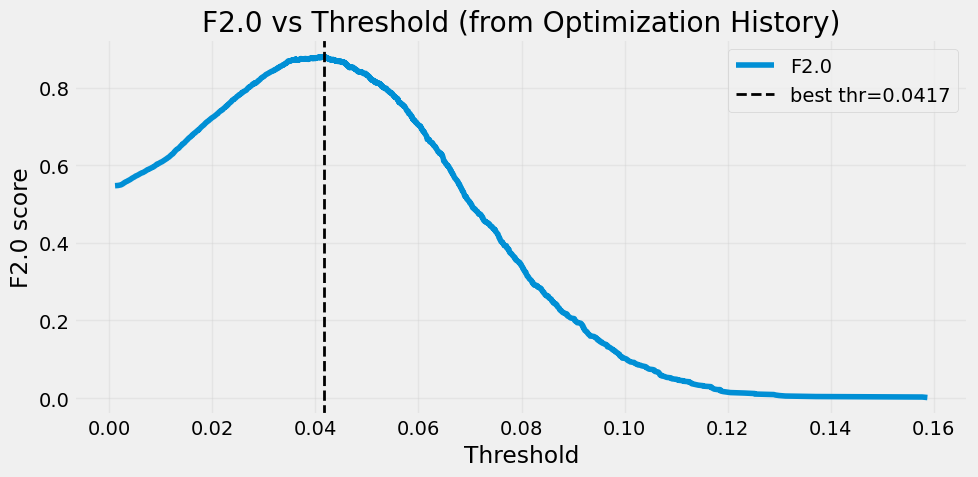

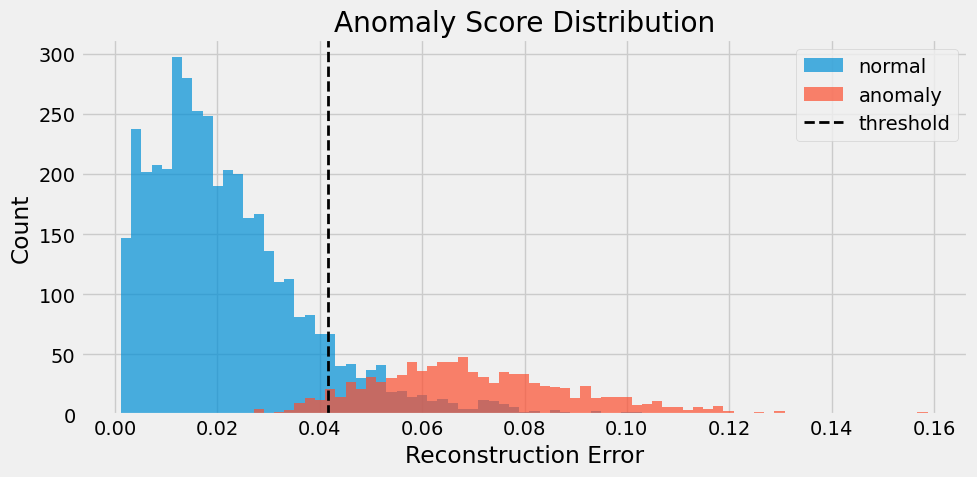

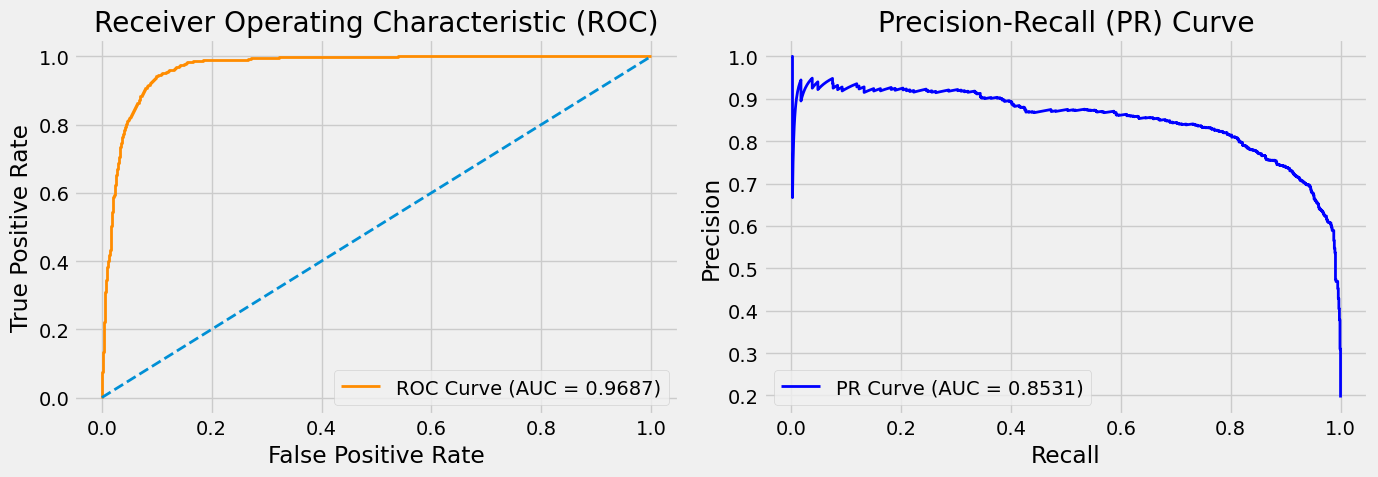

In [60]:
normal_scores = score_images(model, val_normal[0], device=device, criterion_fn=criterion_fn)
anomaly_scores = score_images(model, val_anomaly[0], device=device, criterion_fn=criterion_fn)

beta = 2.0
best_threshold, best_results = optimize_fbeta_threshold(
    val_normal_scores=normal_scores,
    val_anomaly_scores=anomaly_scores,
    beta = beta
)

print_metrics(
    y_true = best_results["y_true"],
    y_scores = best_results["y_scores"],
    threshold = best_threshold,
    beta = beta
)

plot_fbeta_vs_threshold(best_results['thresholds'], best_results['fbeta_vals'], best_threshold, beta, save_path=SAVE_DIR / f"exp1_f{beta}_vs_threshold.png")
plot_anomaly_distribution(normal_scores, anomaly_scores, best_threshold, save_path=SAVE_DIR / "exp1_anomaly_score_distribution.png")
plot_performance_curves(best_results["y_true"], best_results["y_scores"], save_path=SAVE_DIR / "exp1_performance_curves.png")

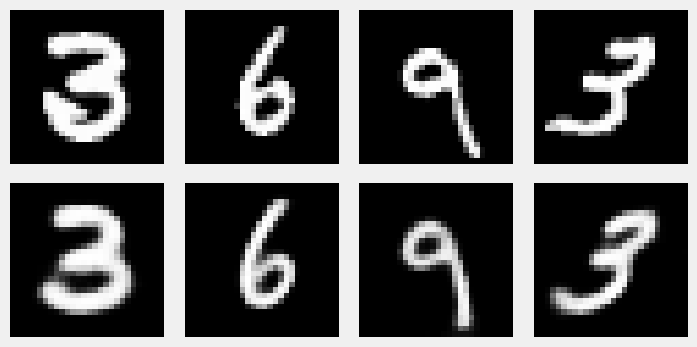

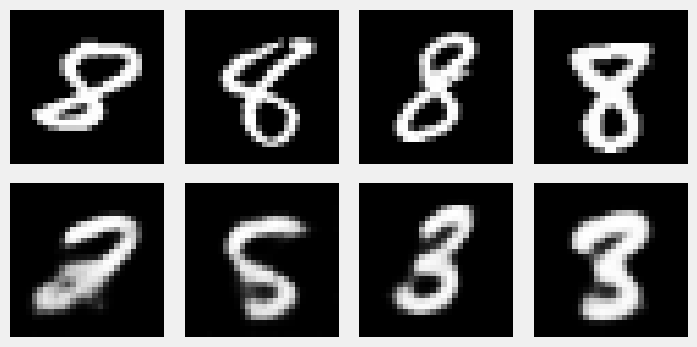

In [ ]:
val_normal_og, val_normal_rec = get_reconstructions(model, val_normal[0][:4], device)
val_anomaly_og, val_anomaly_rec = get_reconstructions(model, val_anomaly[0][:4], device)

# Reconstruction examples for val_normal
plot_reconstructions(val_normal_og, val_normal_rec, '', save_path=SAVE_DIR / 'exp1_rec_val_normal.png')

# Reconstruction examples for val_anomaly
plot_reconstructions(val_anomaly_og, val_anomaly_rec, '', save_path=SAVE_DIR / 'exp1_rec_val_anomaly.png')

## Exp.2 Training Logic (Self-Supervised Masking)

To force the model to learn a deeper, more robust semantic representation of "normal" digits, we propose implementing a denoising and inpainting framework. By applying Gaussian noise to the input images during training, the network will be forced to infer missing spatial data based purely on the manifold of normal data.

In [281]:
class GaussianNoiseCorruption:
    def __init__(self, mean: float = 0.0, std: float = 0.2):
        self.mean = mean
        self.std = std

    def __call__(self, img_tensor):
        corrupted = img_tensor.clone()
        noise = torch.randn_like(corrupted) * self.std + self.mean
        corrupted = corrupted + noise
        return torch.clamp(corrupted, 0.0, 1.0)

corruption_cls = GaussianNoiseCorruption
corruption_fn = corruption_cls()

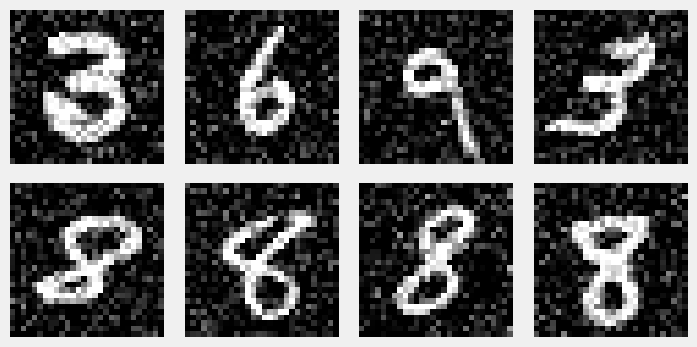

In [282]:
# Examples of corrupted digits
plot_reconstructions(
    corruption_fn(val_normal[0][:4]),
    corruption_fn(val_anomaly[0][:4]),
    '',
    save_path=SAVE_DIR / 'exp2_mask_example.png'
)

In [46]:
val_normal_X = val_normal[0].to(device)
val_anomaly_X = val_anomaly[0].to(device)

per_model_data = {
    "std": [],
    "losses": []
}

criterion_fn = criterion_cls(alpha=best_alpha)

def ae_score_callback(std: float) -> Tuple[np.ndarray, np.ndarray]:
    set_seed(SEED)
    train_loader.generator.manual_seed(SEED)

    model = Autoencoder(**autoencoder_kwargs).to(device)
    optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)
    current_corruption = corruption_cls(std=std)

    losses = train_autoencoder(
        model = model,
        train_loader = train_loader,
        criterion_fn = criterion_fn,
        optimizer = optimizer,
        device = device,
        loss_eps = 1e-3,
        patience = 5,
        max_epochs = 100,
        corruption_fn = current_corruption,
        verbose = True
    )

    per_model_data["std"].append(std)
    per_model_data["losses"].append(losses)

    val_normal_scores = score_images(model, val_normal_X, device, criterion_fn = criterion_fn)
    val_anomaly_scores = score_images(model, val_anomaly_X, device, criterion_fn = criterion_fn)

    return val_normal_scores, val_anomaly_scores

best_std, best_auc, history = optimize_via_zooming_grid(
    score_fn = ae_score_callback,
    param_min = 0.0,
    param_max = 1.0,
    size = 5,
    depth = 3,
    param_name = "std",
    is_integer = False,
    verbose = True
)

print(f"Best std: {best_std:.5e} with PR AUC: {best_auc:.5e}")


Zoom Step 1/3 Interval: [0.0000, 1.0000]
std        | PR AUC    


[Early Stopped at Epoch 39]: : 39 epoch [00:44,  1.13s/ epoch, Loss=2.367e-02, Best=2.444e-02, Patience=5/5]


0.0000     | 0.8377    


[Early Stopped at Epoch 38]: : 38 epoch [00:42,  1.13s/ epoch, Loss=2.525e-02, Best=2.608e-02, Patience=5/5]


0.2000     | 0.7975    


...

0.0310     | 0.8092    


[Early Stopped at Epoch 39]: : 39 epoch [00:46,  1.20s/ epoch, Loss=2.352e-02, Best=2.426e-02, Patience=5/5]


0.0470     | 0.7414    


[Early Stopped at Epoch 39]: : 39 epoch [00:54,  1.41s/ epoch, Loss=2.364e-02, Best=2.441e-02, Patience=5/5]

0.0620     | 0.8091    
Best std: 0.00000e+00 with PR AUC: 8.37737e-01


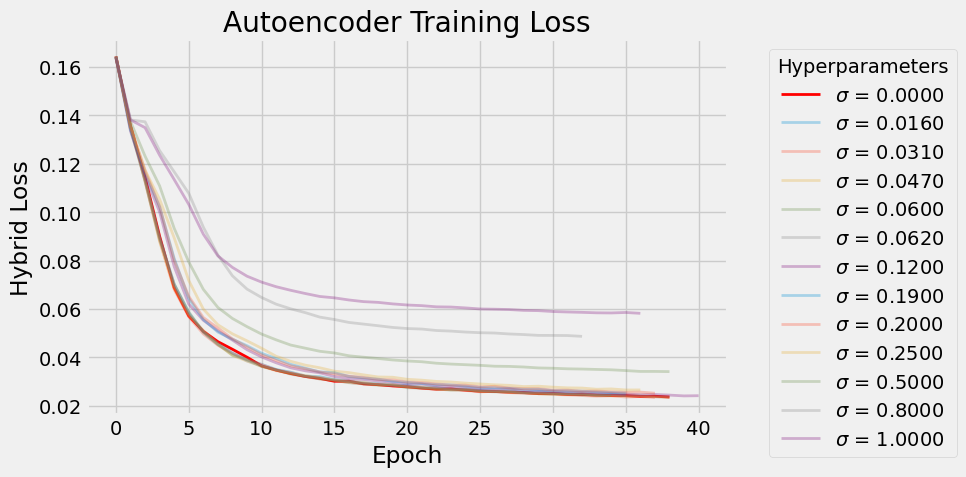

In [64]:
std_loss_dict = dict(zip(per_model_data["std"], per_model_data["losses"]))

plot_loss(
    losses=std_loss_dict,
    highlight_key=best_std,
    label_prefix=r"$\sigma$ = ",
    loss_prefix="Hybrid ",
    legend_title="Hyperparameters",
    save_path=SAVE_DIR / "exp2_all_a_epoch_loss.png"
)

In [71]:
set_seed(SEED)
train_loader.generator.manual_seed(SEED)

model = Autoencoder(**autoencoder_kwargs).to(device)
optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)
criterion_fn = criterion_cls(alpha=best_alpha)
corruption_fn = corruption_cls(std=best_std)

losses = train_autoencoder(
    model = model,
    train_loader = train_loader,
    criterion_fn = criterion_fn,
    optimizer = optimizer,
    device = device,
    loss_eps = 1e-4,
    patience = 5,
    max_epochs = 100,
    corruption_fn = corruption_fn,
    verbose = True
)

[Early Stopped at Epoch 78]: : 78 epoch [01:30,  1.16s/ epoch, Loss=2.068e-02, Best=2.074e-02, Patience=5/5]


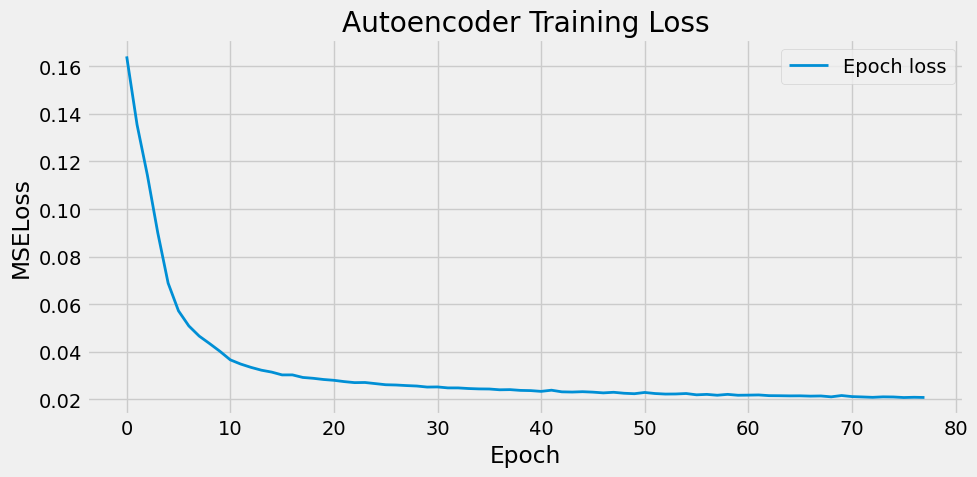

In [72]:
plot_loss(
    losses,
    label_prefix = "Hybrid ",
    save_path = SAVE_DIR / "exp2_best_model_epoch_loss.png"
)

--- Evaluation Metrics ---
Best threshold for F2.0-score: 0.041686
Accuracy:  0.9073
Precision: 0.6922
Recall:    0.9446
F2.0 score:  0.8804

Confusion matrix:
[[3613  409]
 [  54  920]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9853    0.8983    0.9398      4022
         1.0     0.6922    0.9446    0.7990       974

    accuracy                         0.9073      4996
   macro avg     0.8388    0.9214    0.8694      4996
weighted avg     0.9281    0.9073    0.9123      4996



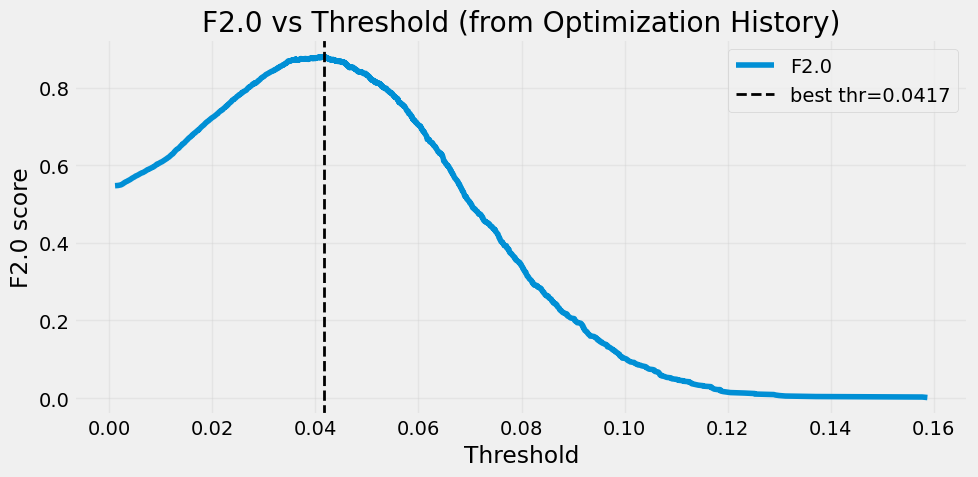

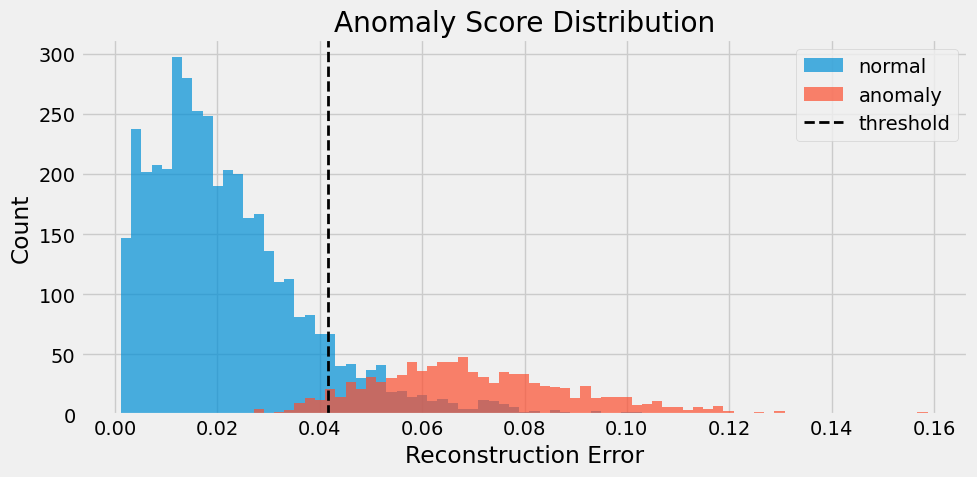

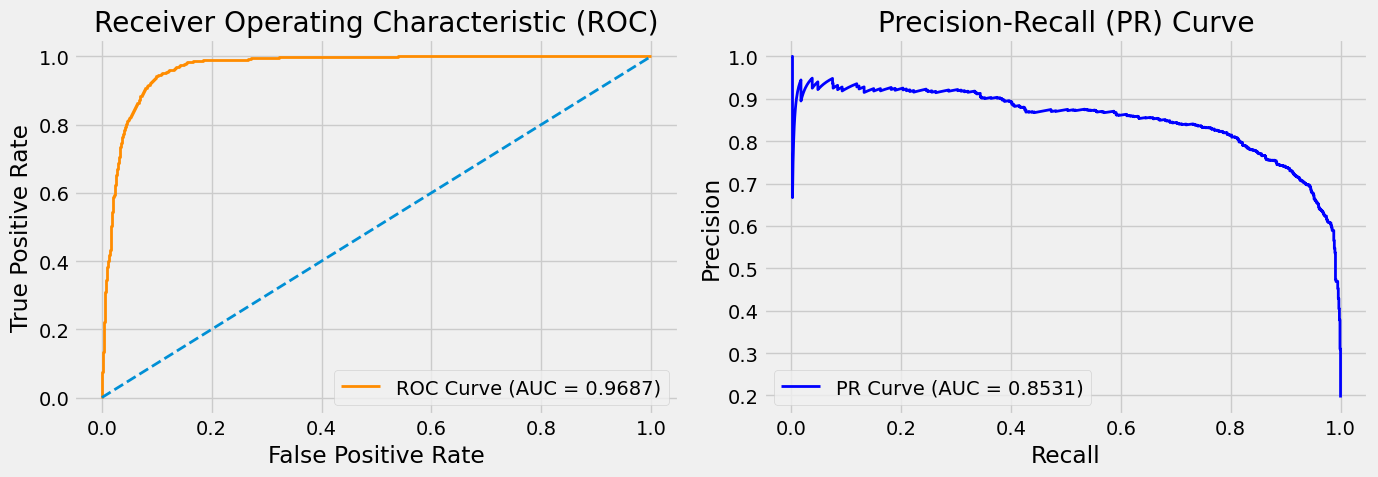

In [73]:
normal_scores = score_images(model, corruption_fn(val_normal[0]), device=device, criterion_fn=criterion_fn)
anomaly_scores = score_images(model, corruption_fn(val_anomaly[0]), device=device, criterion_fn=criterion_fn)

beta = 2.0
best_threshold, best_results = optimize_fbeta_threshold(
    val_normal_scores=normal_scores,
    val_anomaly_scores=anomaly_scores,
    beta = beta
)

print_metrics(
    y_true = best_results["y_true"],
    y_scores = best_results["y_scores"],
    threshold = best_threshold,
    beta = beta
)

plot_fbeta_vs_threshold(best_results['thresholds'], best_results['fbeta_vals'], best_threshold, beta, save_path=SAVE_DIR / f"exp2_f{beta}_vs_threshold.png")
plot_anomaly_distribution(normal_scores, anomaly_scores, best_threshold, save_path=SAVE_DIR / "exp2_anomaly_score_distribution.png")
plot_performance_curves(best_results["y_true"], best_results["y_scores"], save_path=SAVE_DIR / "exp2_performance_curves.png")

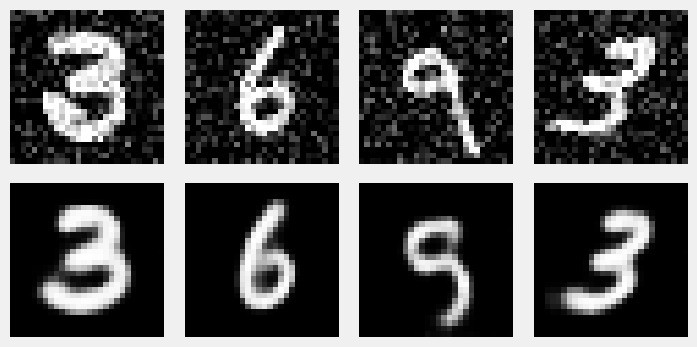

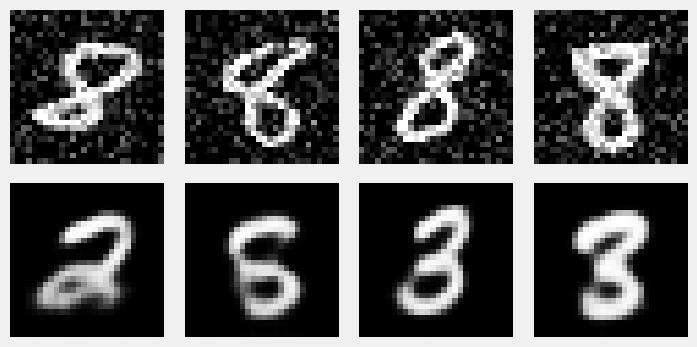

In [284]:
val_normal_og, val_normal_rec = get_reconstructions(model, corruption_fn(val_normal[0][:4]), device)
val_anomaly_og, val_anomaly_rec = get_reconstructions(model, corruption_fn(val_anomaly[0][:4]), device)

# Reconstruction examples for val_normal
plot_reconstructions(val_normal_og, val_normal_rec, '', save_path=SAVE_DIR / 'exp2_rec_val_normal.png')

# Reconstruction examples for val_anomaly
plot_reconstructions(val_anomaly_og, val_anomaly_rec, '', save_path=SAVE_DIR / 'exp2_rec_val_anomaly.png')

## Exp.3 Inference Logic (Transformation Ensembles)

To increase confidence during inference, we propose evaluating an input transformation ensemble. Specifically, we will pass multiple rotated variations of a single input image through the network. Because rotation preserves the semantic structure of the digit while entirely altering the pixel-level array, we expect the Autoencoder to exhibit low variance in reconstruction error for normal digits across rotations, but high, unstable variance for anomalous digits.

In [245]:
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

def get_single_image_rotations(model, single_image, device, angles):
    model.eval()
    img_tensor = single_image.reshape(1, 1, 28, 28).to(device)
    originals = []
    reconstructions = []
    with torch.no_grad():
        for angle in angles:
            rotated_img = TF.rotate(img_tensor, angle, interpolation=InterpolationMode.BILINEAR)
            recon = model(rotated_img)
            # Squeeze down to (28, 28)
            originals.append(rotated_img.cpu().numpy().squeeze()) 
            reconstructions.append(recon.cpu().numpy().squeeze())
    return np.array(originals), np.array(reconstructions)

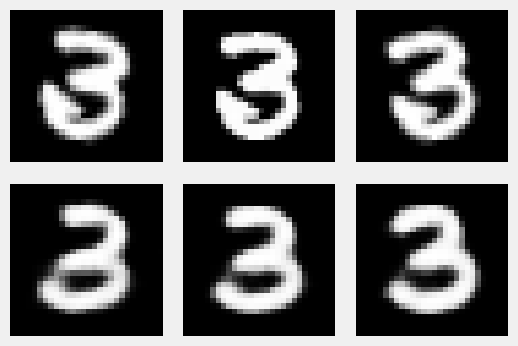

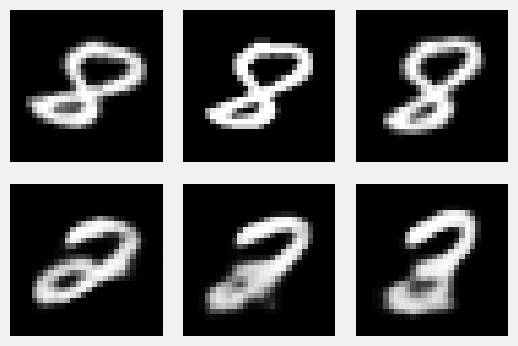

In [277]:
angles = [-10, 0, 10]
norm_orig, norm_recon = get_single_image_rotations(model, val_normal[0][0], device, angles=angles)
anom_orig, anom_recon = get_single_image_rotations(model, val_anomaly[0][0], device, angles=angles)

plot_reconstructions(
    originals=norm_orig, 
    reconstructions=norm_recon, 
    title="",
    # title=f"Normal Digit Rotations ({min(angles)}$\\degree$ to +{max(angles)}$\\degree$)", 
    n=len(angles),
    save_path=SAVE_DIR / 'exp3_rec_val_normal_rotations.png'
)

plot_reconstructions(
    originals=anom_orig, 
    reconstructions=anom_recon, 
    title="",
    # title=f"Anomaly Digit Rotations ({min(angles)}$\\degree$ to +{max(angles)}$\\degree$)", 
    n=len(angles),
    save_path=SAVE_DIR / 'exp3_rec_val_anomaly_rotations.png'
)

In [250]:
import itertools

def score_images_variation(model, images, device, criterion_fn, reduction="none"):
    """
    Evaluates anomaly confidence using Test-Time Augmentation (TTA).
    Calculates the variance of errors of all unique pairwise combinations of reconstructed images.
    """
    model.eval()
    images = images.reshape(images.shape[0], 1, 28, 28)

    if images.device != device:
        images = images.to(device)

    angles = [-40, -30, -20, 0, 20, 30, 40]
    reconstructions = []

    # Collect all reconstructions across all angles
    with torch.no_grad():
        for angle in angles:
            rotated_imgs = TF.rotate(images, angle, interpolation=InterpolationMode.BILINEAR)
            recon = model(rotated_imgs)
            reconstructions.append(recon)

    # Compute all unique pairwise errors between reconstructions
    pairwise_errors = []
    for recon_a, recon_b in itertools.combinations(reconstructions, 2):
        pair_error = criterion_fn(recon_a, recon_b, reduction=reduction)
        if pair_error.ndim > 1:
            pair_error = torch.mean(pair_error, dim=tuple([i for i in range(1, pair_error.ndim)]))
        pairwise_errors.append(pair_error)

    stacked_pairwise = torch.stack(pairwise_errors, dim=0)
    mean_pairwise_scores = torch.var(stacked_pairwise, dim=0)

    return mean_pairwise_scores.cpu().numpy()

In [268]:
base_normal_scores = score_images(model, val_normal[0], device, criterion_fn)
base_anomaly_scores = score_images(model, val_anomaly[0], device, criterion_fn)

var_normal_scores = score_images_variation(
    model = model,
    images = val_normal[0],
    device = device,
    criterion_fn = criterion_fn
)

var_anomaly_scores = score_images_variation(
    model = model,
    images = val_anomaly[0],
    device = device,
    criterion_fn = criterion_fn
)

def lambda_score_callback(lambda_weight: float) -> Tuple[np.ndarray, np.ndarray]:
    blended_normal = base_normal_scores + (lambda_weight * var_normal_scores)
    blended_anomaly = base_anomaly_scores + (lambda_weight * var_anomaly_scores)
    return blended_normal, blended_anomaly

best_lambda, best_auc, history = optimize_via_zooming_grid(
    score_fn = lambda_score_callback,
    param_min = 0.0,
    param_max = 10.0,
    size = 11,
    depth = 2,
    param_name = "lambda_weight",
    is_integer = False,
    verbose = False
)

print(f"Best lambda_weight: {best_lambda:.5e} with PR AUC: {best_auc:.5e}")


Best lambda_weight: 4.60000e+00 with PR AUC: 8.65754e-01


--- Evaluation Metrics ---
Best threshold for F2.0-score: 0.057147
Accuracy:  0.9129
Precision: 0.7040
Recall:    0.9548
F2.0 score:  0.8913

Confusion matrix:
[[3631  391]
 [  44  930]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9880    0.9028    0.9435      4022
         1.0     0.7040    0.9548    0.8105       974

    accuracy                         0.9129      4996
   macro avg     0.8460    0.9288    0.8770      4996
weighted avg     0.9327    0.9129    0.9176      4996



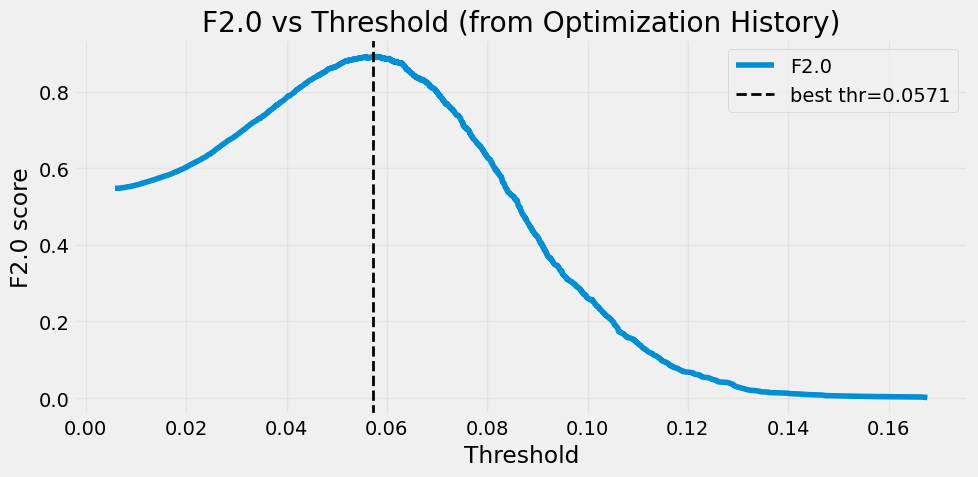

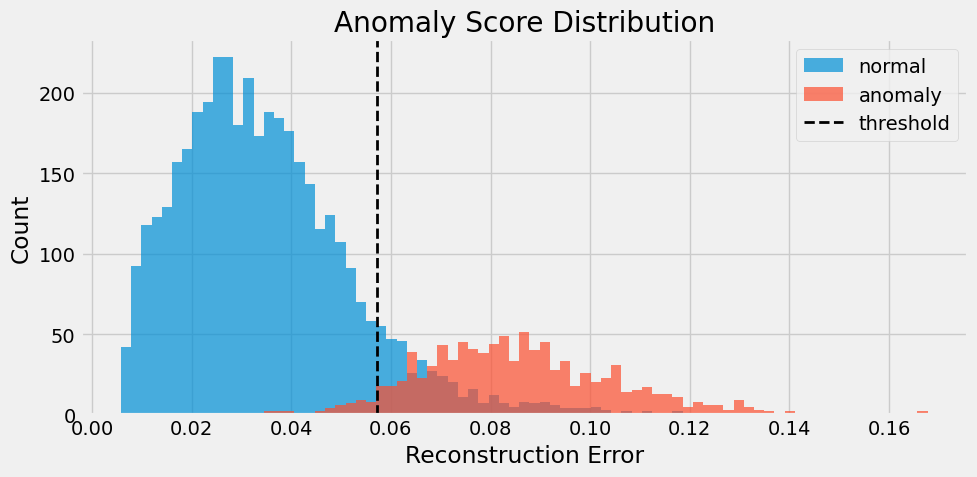

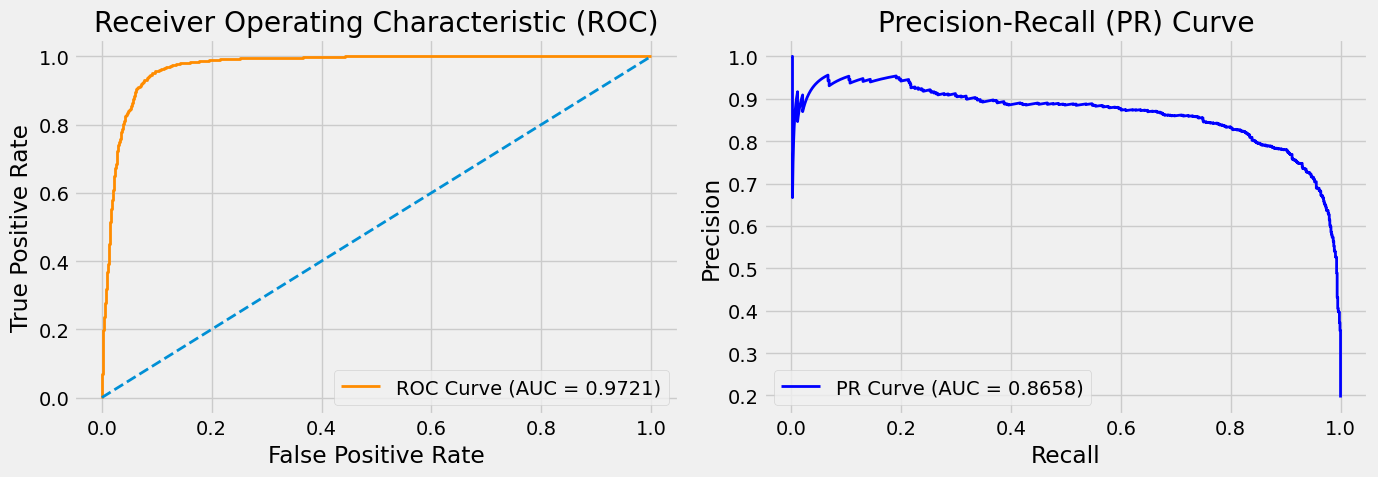

In [ ]:
normal_scores = base_normal_scores + best_lambda * var_normal_scores
anomaly_scores = base_anomaly_scores + best_lambda * var_anomaly_scores

beta = 2.0
best_threshold, best_results = optimize_fbeta_threshold(
    val_normal_scores=normal_scores,
    val_anomaly_scores=anomaly_scores,
    beta = beta
)

print_metrics(
    y_true = best_results["y_true"],
    y_scores = best_results["y_scores"],
    threshold = best_threshold,
    beta = beta
)

plot_fbeta_vs_threshold(best_results['thresholds'], best_results['fbeta_vals'], best_threshold, beta, save_path=SAVE_DIR / f"exp3_f{beta}_vs_threshold.png")
plot_anomaly_distribution(normal_scores, anomaly_scores, best_threshold, save_path=SAVE_DIR / "exp3_anomaly_score_distribution.png")
plot_performance_curves(best_results["y_true"], best_results["y_scores"], save_path=SAVE_DIR / "exp3_performance_curves.png")

In [274]:
config_checkpoint = {
    "autoencoder_kwargs": autoencoder_kwargs,
    "optimizer_kwargs": optimizer_kwargs,
    "alpha": best_alpha,
    "std": best_std,
    "lambda_weight": best_lambda,
    "beta": beta,
}

train_checkpoint = {
    "weights": model.state_dict(),
    "losses": losses,
    "best_threshold": best_threshold,
    "best_results": best_results
}

torch.save(train_checkpoint, DATA_WEIGHTS_DIR / "ae_final_train.pt")
torch.save(config_checkpoint, DATA_WEIGHTS_DIR / "ae_final_config.pt")